# Sigma0 Stability Analysis
Mirrors the sigma1/sigma2 stability notebooks but for **sigma0** (ISI=0).

| Section | Question |
|---------|----------|
| A | Per-experiment-count stability at ISI=0 |
| B | k_stimuli sensitivity |

In [1]:
import sys, os, yaml, torch, random
import matplotlib.pyplot as plt, numpy as np, pandas as pd
from collections import defaultdict
from scipy.stats import norm
from sklearn.metrics import roc_auc_score
from pathlib import Path
from scipy.spatial.distance import pdist
from tqdm.notebook import trange, tqdm

sys.path.append('/om2/user/jmhicks/projects/TextureStreaming/code/')
sys.path.append('/om2/user/bjmedina/auditory-memory/memory/utls/')
sys.path.append('/om2/user/bjmedina/auditory-memory/memory/src/model/')
sys.path.append('/om2/user/bjmedina/auditory-memory/memory/')

from chexture_choolbox.auditorytexture.texture_model import TextureModel
from chexture_choolbox.auditorytexture.helpers import FlattenStats
from texture_prior.params import model_params, statistics_set, texture_dataset
from texture_prior.utils import path
from utls.plotting import ensure_dir
from utls.loading import (load_results_with_exclusion_2, move_sequences_to_used,
                           load_results_with_exclusion_no_dropping)
from utls.runners_v2 import run_experiment_scores, make_noise_schedule
from utls.runners_utils import *
from encoders import *
from utls.toy_experiments import (
    make_isi_n_block_experiment, make_toy_experiment_list, make_multi_isi_toy_experiments,
)
from utls.sigma_fitting import log_mid, make_grid, auc_to_dprime

In [2]:
help(auc_to_dprime)

Help on function auc_to_dprime in module utls.sigma_fitting:

auc_to_dprime(auc_val, eps=1e-06)
    Convert AUC to d'



In [3]:
def load_config(cfg_path):
    cfg_path = Path(cfg_path)
    if not cfg_path.exists():
        raise FileNotFoundError(cfg_path)
    with open(cfg_path) as f:
        return yaml.safe_load(f), cfg_path

def median_pairwise_distance(X, metric="euclidean", n_samples=500, seed=0):
    rng = np.random.default_rng(seed)
    idx = rng.choice(X.shape[0], size=min(n_samples, X.shape[0]), replace=False)
    return float(np.median(pdist(X[idx], metric=metric)))

CONFIG_PATH = (
    "/om2/user/bjmedina/auditory-memory/memory/"
    "model_yamls/v14_three-stage-testing/run_000004.yaml"
)
model_cfg, model_cfg_path = load_config(CONFIG_PATH)
print(model_cfg)

{'results_root': '/om2/user/bjmedina/auditory-memory/memory', 'tag': 'slurm', 'experiment': {'is_multi': True, 'n_seqs': 36, 'n_samples': 50, 'which_task': 0}, 'metric': 'cosine', 'noise_model': {'name': 'three-regime', 'sigma0_min': 1.0, 'sigma0_max': 40.0, 'sigma1_min': 0.1, 'sigma1_max': 40.0, 'sigma2_min': 0.0005, 'sigma2_max': 20.0, 't_step': 5}, 'fitting': {'n_grid': 5, 'n_mc': 32, 'n_refine_iters': 4, 'n_experiments_per_isi': 5, 'k_stimuli_per_exp': 5}, 'run_id': 'run_000004', 'representation': {'type': 'resnet50', 'layer': 'layer4', 'time_avg': False}}


In [4]:
exp_cfg    = model_cfg["experiment"]
which_task = exp_cfg["which_task"]
is_multi   = exp_cfg["is_multi"]
which_isi  = exp_cfg.get("which_isi", None)
isis       = [0, 1, 2, 4, 8, 16, 32, 64] if is_multi else [0, which_isi]
metric     = model_cfg["metric"]
noise_cfg  = model_cfg["noise_model"]
noise_mode = noise_cfg["name"]
t_step     = noise_cfg["t_step"]
repr_cfg   = model_cfg["representation"]
time_avg   = repr_cfg["time_avg"]
encoder_type = repr_cfg["type"]
layer      = repr_cfg.get("layer", None)
pc_dims    = repr_cfg.get("pc_dims", None)

exp_list, all_files, name_to_idx, human_runs, task_name, hr_task_name = (
    load_experiment_data(which_task, which_isi, is_multi, old=False)
)
human_curve  = compute_human_curve(human_runs, is_multi, which_isi)
time_avg_tag = "time_avg" if time_avg else "nontime_avg"
print("ISIs:", isis)
print("Human d':", human_curve)

/om2/user/bjmedina/auditory-memory/memory/utls/runners_utils.py:210: RuntimeWarning: Mean of empty slice
  dprimes.append(np.nanmean(aucs))


ISIs: [0, 1, 2, 4, 8, 16, 32, 64]
Human d': [3.43377107 3.04970169 2.41196502 2.19173132 1.98691922 1.91342635
 1.77766993 1.58677584]


In [88]:
NN_ENCODERS  = {"kell2018", "resnet50"}
encoder_task = "word_speaker_audioset" if encoder_type in NN_ENCODERS else "audioset"
encoder_cfg  = dict(
    encoder_type=encoder_type, model_name=encoder_type, task=encoder_task,
    statistics_dict=statistics_set.statistics, model_params=model_params,
    pc_dims=pc_dims, sr=20000, duration=2.0, rms_level=0.05,
    time_avg=time_avg, device="cuda",
)
if encoder_type in NN_ENCODERS: encoder_cfg["layer"] = layer
if encoder_type == "texture":   encoder_cfg["pc_dims"] = pc_dims

encoder_name = make_encoder_name(encoder_cfg)
encoder      = build_encoder(encoder_cfg)
X            = encode_stimuli(encoder, all_files)
X_np         = X.detach().cpu().numpy()
print("Shape:", X_np.shape, " NaN?", torch.isnan(X).any().item())

d50 = median_pairwise_distance(X_np, metric="cosine")
print(f"d50 = {d50:.6f}")

param_bounds = {
    "sigma0": (3.5, 200),
    "sigma1": (noise_cfg["sigma1_min"] * d50,   noise_cfg["sigma1_max"] * d50),
    "sigma2": (noise_cfg["sigma2_min"] * d50,   noise_cfg["sigma2_max"] * d50),
}
for k, v in param_bounds.items():
    print(f"  {k}: ({v[0]:.6f}, {v[1]:.6f})")

stimulus_pool = sorted({s for seq in exp_list for s in seq})
print(f"Stimulus pool: {len(stimulus_pool)}")

LOADING FROM /om2/user/bjmedina/models/cochdnn/model_directories/resnet50_word_speaker_audioset/
=> loading checkpoint '/om2/user/bjmedina/models/cochdnn/model_checkpoints/audio_rep_training_cochleagram_1/standard_training_word_and_audioset_and_speaker_decay_lr/542752d7-9849-49ff-b84a-6758a81585b4/5_checkpoint.pt'
=> loaded checkpoint '/om2/user/bjmedina/models/cochdnn/model_checkpoints/audio_rep_training_cochleagram_1/standard_training_word_and_audioset_and_speaker_decay_lr/542752d7-9849-49ff-b84a-6758a81585b4/5_checkpoint.pt' (epoch 6)
Shape: (80, 186368)  NaN? False
d50 = 0.479312
  sigma0: (3.500000, 200.000000)
  sigma1: (0.047931, 19.172478)
  sigma2: (0.000240, 9.586239)
Stimulus pool: 80


In [99]:
# ---- fix other sigmas at geometric means ----
sigma1_fixed = log_mid(*param_bounds['sigma1'])
sigma2_fixed = log_mid(*param_bounds['sigma2'])
print(f'Fixed sigma1 = {sigma1_fixed:.6f}')
print(f'Fixed sigma2 = {sigma2_fixed:.6f}')

N_MC      = 5
N_PER_DIM = 15
K_STIM    = 10  # ISI=0 only needs k>=1, but 10 is consistent with sigma1

# param_bounds['sigma0'] = (3.0, 0.5) in the YAML — sort to ensure lo < hi
sigma0_lo = min(param_bounds['sigma0'])
sigma0_hi = max(param_bounds['sigma0'])
sigma0_grid = make_grid(sigma0_lo, sigma0_hi, N_PER_DIM, spacing='log')
print('sigma0 grid:', [f'{v:.5f}' for v in sigma0_grid])

isi_to_hc_idx = {isi_val: i for i, isi_val in enumerate(isis)}
print(f"\nHuman d' at ISI=0: {human_curve[isi_to_hc_idx[0]]:.4f}")

Fixed sigma1 = 0.958624
Fixed sigma2 = 0.047931
sigma0 grid: ['3.50000', '4.67267', '6.23825', '8.32837', '11.11878', '14.84412', '19.81763', '26.45751', '35.32208', '47.15672', '62.95654', '84.05008', '112.21100', '149.80721', '200.00000']

Human d' at ISI=0: 3.4338


In [100]:
def run_sigma_sweep(sigma_name, sigma_grid, fixed_sigmas, exps_by_isi,
                    isi_to_hc_idx, human_curve, N_MC, t_step, noise_mode,
                    metric, X, name_to_idx, base_seed=0):
    """Sweep one sigma over sigma_grid; for each value run N_MC reps.
    Returns list of dicts with sigma_value, mse_mean, mse_std, dprime_mean, dprime_std.
    """
    results = []
    for sig_idx, sigma_val in enumerate(sigma_grid):
        sigmas = dict(fixed_sigmas)
        sigmas[sigma_name] = sigma_val
        mse_per_rep    = []
        dprime_per_rep = []

        for rep in trange(N_MC, desc=f"{sigma_name}={sigma_val:.4g}", leave=False):
            rep_mse = []
            rep_dp  = []
            for isi_val, exps in exps_by_isi.items():
                if not exps: continue
                hc_idx   = isi_to_hc_idx.get(isi_val)
                if hc_idx is None: continue
                human_dp = human_curve[hc_idx]
                run_out  = run_experiment_scores(
                    sigma0=sigmas["sigma0"], sigma1=sigmas["sigma1"], sigma2=sigmas["sigma2"],
                    t_step=t_step, rate=0, noise_mode=noise_mode,
                    metric=metric, X0=X, name_to_idx=name_to_idx,
                    experiment_list=exps, debug=False,
                    seed=base_seed + isi_val*1_000_000 + sig_idx*10_000 + rep,
                )
                
                hits = np.asarray(run_out["hits"]); fas = np.asarray(run_out["fas"])
                            
                # ##############################
                # #target_fpr = np.array([0.001, 0.05, 0.1,  0.2, 0.3, 0.4, 0.5, 0.7, 0.9, 0.99], dtype=float)
                # target_fpr = np.linspace(0, 1.1, 1000)
        
                # y_true = np.concatenate([np.ones(len(hits)), np.zeros(len(fas))])
                # scores = np.concatenate([hits, fas])
        
                # ## UPDATED d' calculation using the sampeld ROC curve
                # # --- ROC for "smaller score = more signal" ---
                # P = (y_true == 1.0).sum()
                # N = (y_true == 0.0).sum()
                
                # thr = np.unique(np.sort(scores))  # candidate thresholds (low -> high)
                # tpr = np.array([(scores[y_true==1.0] <= t).sum()/P for t in thr])
                # fpr = np.array([(scores[y_true==0.0] <= t).sum()/N for t in thr])
                
                # # keep one point per desired FAR by choosing the closest available FAR
                # idx = np.array([np.argmin(np.abs(fpr - f)) for f in target_fpr])
                # #idx = np.unique(idx)  # drop duplicates (can happen when data is coarse)
                
                # fpr_s = fpr[idx]
                # tpr_s = tpr[idx]
                
                # # AUROC over these sampled points (sort by FPR first)
                # order = np.argsort(fpr_s)
                # #order = np.lexsort((-tpr, fpr))
                # #auroc = np.trapz(tpr[order], fpr[order])
                # auroc = np.trapz(tpr_s[order], fpr_s[order])
                # ##############################
                from sklearn.metrics import roc_auc_score


                hits = np.asarray(run_out["hits"])
                fas  = np.asarray(run_out["fas"])
                
                y_true = np.concatenate([np.ones(len(hits)), np.zeros(len(fas))])
                scores = np.concatenate([hits, fas])
                P, N = (y_true == 1).sum(), (y_true == 0).sum()
                
                thr = np.unique(np.sort(scores))
                tpr = np.array([(scores[y_true == 1] <= t).sum() / P for t in thr])
                fpr = np.array([(scores[y_true == 0] <= t).sum() / N for t in thr])
                
                # Upper-envelope: for each unique fpr, retain max tpr
                unique_fpr = np.unique(fpr)
                max_tpr = np.array([tpr[fpr == f].max() for f in unique_fpr])
                
                # Ensure ROC is anchored at (0,0) and (1,1)
                if unique_fpr[0] > 0:
                    unique_fpr = np.concatenate([[0.0], unique_fpr])
                    max_tpr    = np.concatenate([[0.0], max_tpr])
                if unique_fpr[-1] < 1:
                    unique_fpr = np.concatenate([unique_fpr, [1.0]])
                    max_tpr    = np.concatenate([max_tpr,    [1.0]])
                
                # Uniformly tile FPR axis and interpolate tpr from upper envelope
                target_fpr = np.linspace(0, 1, 1000)
                tpr_s = np.interp(target_fpr, unique_fpr, max_tpr)
                auroc = np.trapz(tpr_s, target_fpr)

                dp = auc_to_dprime(auroc, eps=1e-4)
                rep_mse.append((dp - human_dp)**2)
                rep_dp.append(dp)

                
                # plt.plot(fpr_s[order], tpr_s[order])
                # plt.scatter(fpr_s[order], tpr_s[order], alpha=0.2, label=f"auroc:{auroc}")
                # plt.legend()
                # plt.show()

                # eps_ = np.geomspace(1e-15, 1e-3, 100)

                # dps = []
                # for ep in eps_:
                #     dp_ = auc_to_dprime(auroc, eps=ep)
                #     dps.append(dp_)
                # plt.hist(dps, bins=100)
                # plt.show()
                # For a single (sigma0, ISI) pair, compute both AUROCs
                hits, fas = np.asarray(run_out["hits"]), np.asarray(run_out["fas"])
                y_true = np.concatenate([np.ones(len(hits)), np.zeros(len(fas))])
                scores  = np.concatenate([hits, fas])
                
                auroc_sklearn = roc_auc_score(y_true, -scores)  # negated: lower = signal
                # compare against your manual auroc
                                
            if rep_mse:
                mse_per_rep.append(np.mean(rep_mse))
                dprime_per_rep.append(np.mean(rep_dp))

        results.append({
            "sigma_value":  sigma_val,
            "mse_mean":     np.mean(mse_per_rep)    if mse_per_rep    else np.nan,
            "mse_std":      np.std(mse_per_rep)     if mse_per_rep    else np.nan,
            "dprime_mean":  np.mean(dprime_per_rep) if dprime_per_rep else np.nan,
            "dprime_std":   np.std(dprime_per_rep)  if dprime_per_rep else np.nan,
        })
    return results

def run_sigma_sweep_old(sigma_name, sigma_grid, fixed_sigmas, exps_by_isi,
                    isi_to_hc_idx, human_curve, N_MC, t_step, noise_mode,
                    metric, X, name_to_idx, base_seed=0):
    """Sweep one sigma over sigma_grid; for each value run N_MC reps.
    Returns list of dicts with sigma_value, mse_mean, mse_std, dprime_mean, dprime_std.
    """
    results = []
    for sig_idx, sigma_val in enumerate(sigma_grid):
        sigmas = dict(fixed_sigmas)
        sigmas[sigma_name] = sigma_val
        mse_per_rep    = []
        dprime_per_rep = []

        for rep in trange(N_MC, desc=f"{sigma_name}={sigma_val:.4g}", leave=False):
            rep_mse = []
            rep_dp  = []
            for isi_val, exps in exps_by_isi.items():
                if not exps: continue
                hc_idx   = isi_to_hc_idx.get(isi_val)
                if hc_idx is None: continue
                human_dp = human_curve[hc_idx]
                run_out  = run_experiment_scores(
                    sigma0=sigmas["sigma0"], sigma1=sigmas["sigma1"], sigma2=sigmas["sigma2"],
                    t_step=t_step, rate=0, noise_mode=noise_mode,
                    metric=metric, X0=X, name_to_idx=name_to_idx,
                    experiment_list=exps, debug=False,
                    seed=base_seed + isi_val*1_000_000 + sig_idx*10_000 + rep,
                )
                hits = np.asarray(run_out["hits"]); fas = np.asarray(run_out["fas"])
                if len(hits)==0 or len(fas)==0: continue
                y = np.concatenate([np.ones(len(hits)), np.zeros(len(fas))])
                dp = auc_to_dprime(roc_auc_score(y, -np.concatenate([hits,fas])))
                rep_mse.append((dp - human_dp)**2)
                rep_dp.append(dp)
            if rep_mse:
                mse_per_rep.append(np.mean(rep_mse))
                dprime_per_rep.append(np.mean(rep_dp))

        results.append({
            "sigma_value":  sigma_val,
            "mse_mean":     np.mean(mse_per_rep)    if mse_per_rep    else np.nan,
            "mse_std":      np.std(mse_per_rep)     if mse_per_rep    else np.nan,
            "dprime_mean":  np.mean(dprime_per_rep) if dprime_per_rep else np.nan,
            "dprime_std":   np.std(dprime_per_rep)  if dprime_per_rep else np.nan,
        })
    return results




## Section A: Per-Experiment-Count Stability

ISI=0 only. Vary n_experiments in [20, 40, 80, 160].

In [101]:
EXP_COUNTS = [20]#, 80]
per_nexp_results = {}

hc_idx = isi_to_hc_idx[0]
print(f"=== ISI=0  human d' = {human_curve[hc_idx]:.4f} ===")

for n_exp in EXP_COUNTS:
    exps = make_toy_experiment_list(
        stimulus_pool, isi=0, n_experiments=n_exp,
        k_stimuli=K_STIM, seed=n_exp)
    print(f'  n_exp={n_exp}: {len(exps)} exps, '
          f'avg len {np.mean([len(e) for e in exps]):.1f}')

    res = run_sigma_sweep(
        sigma_name='sigma0', sigma_grid=sigma0_grid,
        fixed_sigmas={'sigma0': 0, 'sigma1': sigma1_fixed, 'sigma2': sigma2_fixed},
        exps_by_isi={0: exps},
        isi_to_hc_idx=isi_to_hc_idx, human_curve=human_curve,
        N_MC=N_MC, t_step=t_step, noise_mode=noise_mode,
        metric=metric, X=X, name_to_idx=name_to_idx,
        base_seed=n_exp * 1_000_000,
    )
    per_nexp_results[f"{n_exp} new"] = res

    res = run_sigma_sweep_old(
        sigma_name='sigma0', sigma_grid=sigma0_grid,
        fixed_sigmas={'sigma0': 0, 'sigma1': sigma1_fixed, 'sigma2': sigma2_fixed},
        exps_by_isi={0: exps},
        isi_to_hc_idx=isi_to_hc_idx, human_curve=human_curve,
        N_MC=N_MC, t_step=t_step, noise_mode=noise_mode,
        metric=metric, X=X, name_to_idx=name_to_idx,
        base_seed=n_exp * 1_000_000,
    )
    per_nexp_results[f"{n_exp} old"] = res

print('Done.')

=== ISI=0  human d' = 3.4338 ===
  n_exp=20: 20 exps, avg len 20.0


sigma0=3.5:   0%|          | 0/5 [00:00<?, ?it/s]

sigma0=4.673:   0%|          | 0/5 [00:00<?, ?it/s]

sigma0=6.238:   0%|          | 0/5 [00:00<?, ?it/s]

sigma0=8.328:   0%|          | 0/5 [00:00<?, ?it/s]

...

sigma0=84.05:   0%|          | 0/5 [00:00<?, ?it/s]

sigma0=112.2:   0%|          | 0/5 [00:00<?, ?it/s]

sigma0=149.8:   0%|          | 0/5 [00:00<?, ?it/s]

sigma0=200:   0%|          | 0/5 [00:00<?, ?it/s]

Done.


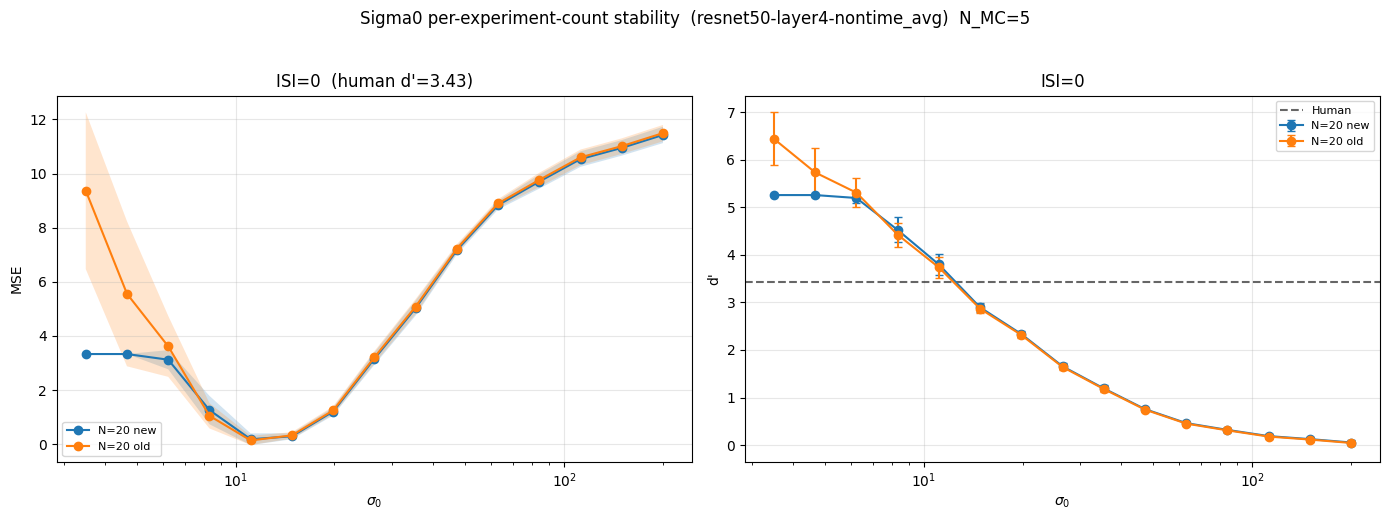

In [102]:
hc_idx = isi_to_hc_idx[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MSE panel
ax = axes[0]
for n_exp, res in per_nexp_results.items():
    df = pd.DataFrame(res)
    ax.plot(df.sigma_value, df.mse_mean, 'o-', label=f'N={n_exp}')
    ax.fill_between(df.sigma_value, df.mse_mean - df.mse_std,
                    df.mse_mean + df.mse_std, alpha=0.2)
ax.set_xscale('log')
ax.set_xlabel(r'$\sigma_0$')
ax.set_ylabel('MSE')
ax.set_title(f'ISI=0  (human d\'={human_curve[hc_idx]:.2f})')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# d' panel
ax = axes[1]
for n_exp, res in per_nexp_results.items():
    df = pd.DataFrame(res)
    ax.errorbar(df.sigma_value, df.dprime_mean, yerr=df.dprime_std,
                fmt='o-', capsize=3, label=f'N={n_exp}')
ax.axhline(human_curve[hc_idx], color='k', ls='--', label='Human', alpha=0.6)
ax.set_xscale('log'); ax.set_xlabel(r'$\sigma_0$'); ax.set_ylabel("d'")
ax.set_title('ISI=0'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.suptitle(f'Sigma0 per-experiment-count stability  ({encoder_type}-{layer}-{time_avg_tag})  N_MC={N_MC}', y=1.03)
plt.tight_layout(); plt.show()

In [79]:
from scipy.stats import norm
# ceiling d' given eps=1e-4
print(norm.ppf(1 - 1e-4) - norm.ppf(1e-4))

7.438032970911389


## Section B: k_stimuli Sensitivity

Fixed n_exp=40. Test how the number of distinct stimuli per experiment affects the MSE landscape.

In [ ]:
K_VALUES    = [5, 10]
N_EXP_FIXED = 40
k_results   = {}

for k_stim in K_VALUES:
    exps = make_toy_experiment_list(
        stimulus_pool, isi=0, n_experiments=N_EXP_FIXED,
        k_stimuli=k_stim, seed=k_stim * 7)
    print(f'k_stim={k_stim}: {len(exps)} exps, '
          f'avg len {np.mean([len(e) for e in exps]):.1f}')
    res = run_sigma_sweep(
        sigma_name='sigma0', sigma_grid=sigma0_grid,
        fixed_sigmas={'sigma0': 0, 'sigma1': sigma1_fixed, 'sigma2': sigma2_fixed},
        exps_by_isi={0: exps},
        isi_to_hc_idx=isi_to_hc_idx, human_curve=human_curve,
        N_MC=N_MC, t_step=t_step, noise_mode=noise_mode,
        metric=metric, X=X, name_to_idx=name_to_idx,
        base_seed=900_000_000 + k_stim * 1_000_000,
    )
    k_results[k_stim] = res

print('Done.')

In [ ]:
plt.figure(figsize=(8, 5))
for k_stim, res in k_results.items():
    df = pd.DataFrame(res)
    plt.plot(df.sigma_value, df.mse_mean, 'o-', label=f'k={k_stim}')
    plt.fill_between(df.sigma_value, df.mse_mean - df.mse_std,
                     df.mse_mean + df.mse_std, alpha=0.2)
plt.xscale('log'); plt.xlabel(r'$\sigma_0$'); plt.ylabel('MSE')
plt.title(f'Sigma0 k_stimuli sensitivity  n_exp={N_EXP_FIXED}, N_MC={N_MC}')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Summary

*(Fill in after running)*

**Recommended Stage A settings:**

In [ ]:
print('Cost estimates (run_experiment_scores calls per fit):')
print(f'  Current: n_grid=15, n_mc=32, n_refine=2, 1 ISI = {15*32*1*2}')
for n_mc in [16, 32]:
    for n_grid in [8, 10, 15]:
        print(f'  n_grid={n_grid} n_mc={n_mc}: {n_grid*n_mc*1*2}')